# Classifier Metrics: Choosing and Tuning for Real Applications

A diabetes-screening model that is 99% accurate but misses one in ten cases is useless — and a spell-checker that flags correct words every other sentence gets turned off. **Not all errors are equal**, so the metric you optimize must match the business constraint.

In this notebook we learn to:

- Turn model **probabilities** into class predictions with a **threshold**.
- Compare classifiers with **summary metrics** (AUROC, AUPRC) before choosing one.
- Tune the operating point for three real-world patterns, leaning on scikit-learn's own [threshold-tuning tools](https://scikit-learn.org/stable/modules/classification_threshold.html): **Minimize false negatives** (recall-first).

We'll demonstrate using the Pima diabetes dataset.

In [1]:
# https://pandas.pydata.org/docs/
import pandas as pd

# https://matplotlib.org/
import matplotlib.pyplot as plt

# https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_openml.html
from sklearn.datasets import fetch_openml

# https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
# https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TunedThresholdClassifierCV.html
from sklearn.model_selection import train_test_split, TunedThresholdClassifierCV

# https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
from sklearn.linear_model import LogisticRegression

# https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
from sklearn.ensemble import RandomForestClassifier

# https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html
from sklearn.preprocessing import StandardScaler

# https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.make_pipeline.html
from sklearn.pipeline import make_pipeline

# https://scikit-learn.org/stable/modules/model_evaluation.html#classification-metrics
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    average_precision_score,
    make_scorer,
    precision_score,
    recall_score,
    roc_auc_score,
)

## The workflow

Every case study in this notebook follows the same four steps:

1. **Split** the data into train and test sets.
2. **Train** two candidate classifiers (`LogisticRegression` and `RandomForestClassifier`).
3. **Compare** with **summary metrics** (AUROC, AUPRC) to pick the better model — this step is independent of the threshold.
4. **Tune the operating point** to hit the application's **point metric**:
   - binary tasks → move the decision threshold with scikit-learn's [`TunedThresholdClassifierCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TunedThresholdClassifierCV.html);

Summary metrics measure *discriminative power* (how well the model ranks positives above negatives). Point metrics measure performance *at one operating point* — what you actually deploy.

In each pattern we report **precision and recall at the default operating point first**, then again after tuning, so the effect of the change is explicit.

## Pattern 1 — Minimize false negatives (recall-first)

**Application:** diabetes screening, cancer screening, fraud alerts, safety-critical detection.

- A **false negative** means missing a true case — sending a diabetic patient home without a follow-up.
- A false positive only triggers extra tests — costly, but far less dangerous.
- **Advice from the lesson:** fix recall $= 100\%$ (catch every true case), then reduce false alarms.

**Dataset:** [Pima Indians Diabetes](https://www.openml.org/d/37) from OpenML — eight routine health measurements, target `tested_positive` vs `tested_negative`. Roughly 35% of patients test positive; a logistic regression reaches AUROC $\approx 0.83$ on this data, so mistakes are common at the default threshold.

### Load data and split

In [2]:
diabetes = fetch_openml("diabetes", version=1, as_frame=True)
X_diabetes = diabetes.data

# Positive class = tested_positive (the case we must not miss)
y_diabetes = (diabetes.target == "tested_positive").astype(int)

print(f"Samples: {X_diabetes.shape[0]:,}")
print(f"Positive rate: {y_diabetes.mean():.1%}")

X_train_dia, X_test_dia, y_train_dia, y_test_dia = train_test_split(
    X_diabetes,
    y_diabetes,
    test_size=0.25,  # hold out 25% for evaluation
    random_state=42,
    stratify=y_diabetes,  # keep the same positive rate in train and test
)

Samples: 768
Positive rate: 34.9%


### Compare models with summary metrics

Before touching the threshold, pick the classifier with better **discriminative power**:

- **AUROC** — area under the ROC curve; probability a random positive ranks above a random negative.
- **AUPRC** — area under the precision-recall curve; expected precision at a random threshold.

In [3]:
log_reg_dia = make_pipeline(
    StandardScaler(),  # scale features so logistic regression converges
    LogisticRegression(max_iter=1000, random_state=42),
)
rf_dia = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,  # use all CPU cores for fitting the forest
)

candidates_dia = {
    "LogisticRegression": log_reg_dia,
    "RandomForest": rf_dia,
}

summary_dia = []
for name, model in candidates_dia.items():
    model.fit(X_train_dia, y_train_dia)
    scores = model.predict_proba(X_test_dia)[:, 1]
    summary_dia.append(
        {
            "model": name,
            "AUROC": roc_auc_score(y_test_dia, scores),
            "AUPRC": average_precision_score(y_test_dia, scores),
        }
    )

summary_dia_df = pd.DataFrame(summary_dia).set_index("model")
summary_dia_df

,AUROC,AUPRC
model,,
LogisticRegression,0.832000,0.712428
RandomForest,0.816179,0.706655


In [4]:
# Pick the model with the higher AUPRC (more informative when classes are imbalanced)
best_name_dia = summary_dia_df["AUPRC"].idxmax()
best_model_dia = candidates_dia[best_name_dia]

print(f"Selected model: {best_name_dia}")

Selected model: LogisticRegression


### Precision and recall *before* tuning

At the default $0.5$ threshold the model already misses several diabetic patients — unacceptable for screening.

In [5]:
y_pred_default_dia = best_model_dia.predict(X_test_dia)

recall_before_dia = recall_score(y_test_dia, y_pred_default_dia)
precision_before_dia = precision_score(y_test_dia, y_pred_default_dia)
fn_before_dia = int(((y_test_dia == 1) & (y_pred_default_dia == 0)).sum())

print("Before tuning (default threshold = 0.5):")
print(f"  Recall:          {recall_before_dia:.3f}")
print(f"  Precision:       {precision_before_dia:.3f}")
print(f"  False negatives: {fn_before_dia} (missed diabetic patients)")

Before tuning (default threshold = 0.5):
  Recall:          0.522
  Precision:       0.648
  False negatives: 32 (missed diabetic patients)


### Tune the threshold with `TunedThresholdClassifierCV`

Instead of scanning thresholds by hand, we let scikit-learn's [`TunedThresholdClassifierCV`](https://scikit-learn.org/stable/modules/classification_threshold.html) search the decision threshold by cross-validation. We tell it *what* to optimize through a custom scorer that encodes the business rule:

- **reward precision only when recall is perfect**, otherwise disqualify the threshold.

The fitted object exposes `best_threshold_` and a ready-to-use `predict` that already applies it.

In [6]:
def precision_at_full_recall(y_true, y_pred):
    """Recall-first objective: precision when recall is perfect, else 0."""
    # A threshold that misses any positive is disqualified (score 0)
    if recall_score(y_true, y_pred, zero_division=0) < 1.0:
        return 0.0
    return precision_score(y_true, y_pred, zero_division=0)


# make_scorer wraps our function so TunedThresholdClassifierCV can evaluate it
recall_first_scorer = make_scorer(precision_at_full_recall)

tuned_dia = TunedThresholdClassifierCV(
    estimator=best_model_dia,  # cloned and refit inside the cross-validation
    scoring=recall_first_scorer,  # the business rule we just defined
    cv=5,  # 5-fold stratified CV to choose the threshold
    refit=True,  # refit on all training data once the threshold is chosen
)
tuned_dia.fit(X_train_dia, y_train_dia)

print("Default threshold: 0.500")
print(f"Tuned threshold:   {tuned_dia.best_threshold_:.3f}")

Default threshold: 0.500
Tuned threshold:   0.002


In [7]:
# predict() already applies the tuned threshold
y_pred_tuned_dia = tuned_dia.predict(X_test_dia)

recall_after_dia = recall_score(y_test_dia, y_pred_tuned_dia)
precision_after_dia = precision_score(y_test_dia, y_pred_tuned_dia)
fn_after_dia = int(((y_test_dia == 1) & (y_pred_tuned_dia == 0)).sum())
fp_after_dia = int(((y_test_dia == 0) & (y_pred_tuned_dia == 1)).sum())

print("After tuning (recall-first):")
print(f"  Recall:          {recall_after_dia:.3f}  (was {recall_before_dia:.3f})")
print(f"  Precision:       {precision_after_dia:.3f}  (was {precision_before_dia:.3f})")
print(f"  False negatives: {fn_after_dia}  (was {fn_before_dia})")
print(f"  False positives: {fp_after_dia}  (extra follow-up tests for non-diabetic patients)")

After tuning (recall-first):
  Recall:          1.000  (was 0.522)
  Precision:       0.349  (was 0.648)
  False negatives: 0  (was 32)
  False positives: 125  (extra follow-up tests for non-diabetic patients)


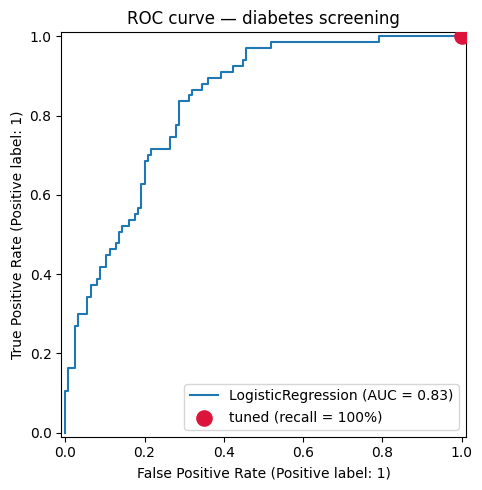

In [8]:
proba_best_dia = best_model_dia.predict_proba(X_test_dia)[:, 1]

fig, ax = plt.subplots(figsize=(6, 5))

RocCurveDisplay.from_predictions(
    y_test_dia,
    proba_best_dia,
    ax=ax,
    name=best_name_dia,
)

# Operating point of the tuned classifier (ROC axes are FPR vs TPR)
tp = ((y_test_dia == 1) & (y_pred_tuned_dia == 1)).sum()
fn = ((y_test_dia == 1) & (y_pred_tuned_dia == 0)).sum()
fp = ((y_test_dia == 0) & (y_pred_tuned_dia == 1)).sum()
tn = ((y_test_dia == 0) & (y_pred_tuned_dia == 0)).sum()
tpr_at_th = tp / (tp + fn)
fpr_at_th = fp / (fp + tn)

ax.scatter(
    fpr_at_th,
    tpr_at_th,
    s=120,
    c="crimson",
    zorder=5,
    label=f"tuned (recall = {recall_after_dia:.0%})",
)
ax.set_title("ROC curve — diabetes screening")
ax.legend()
plt.tight_layout()
plt.show()

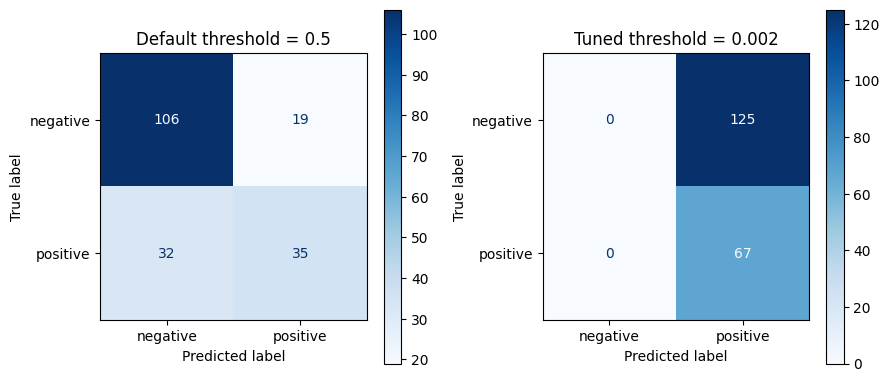

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

for ax, y_pred, title in [
    (axes[0], y_pred_default_dia, "Default threshold = 0.5"),
    (axes[1], y_pred_tuned_dia, f"Tuned threshold = {tuned_dia.best_threshold_:.3f}"),
]:
    ConfusionMatrixDisplay.from_predictions(
        y_test_dia,
        y_pred,
        display_labels=["negative", "positive"],
        cmap="Blues",
        ax=ax,
    )
    ax.set_title(title)

plt.tight_layout()
plt.show()

## Recap

**The two-step process:**

1. Use **summary metrics** (AUROC, AUPRC) to compare and select the best classifier — threshold-free.
2. Tune the **operating point** to optimize the **point metric** that matches your application's error costs:
   - binary → [`TunedThresholdClassifierCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TunedThresholdClassifierCV.html) (or [`FixedThresholdClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.FixedThresholdClassifier.html) to deploy a hand-picked threshold);
